# AICE Associate 모의고사 (신규) 2회: 당뇨병 진단 예측

**과제: 건강 지표 기반 당뇨병 예측**

**도메인: 의료/헬스케어**

**배경:**  
'AICE 헬스케어'는 환자의 건강 검진 데이터를 바탕으로 당뇨병 발병 여부를 조기에 예측하는 AI 진단 보조 시스템을 개발하고자 합니다. 혈당 수치, BMI, 나이 등 간단한 검진 결과만으로도 당뇨병 위험을 사전에 파악할 수 있다면, 환자에게 적절한 생활 습관 교정 및 예방 조치를 안내하는 데 큰 도움이 됩니다.

**데이터셋 설명 (파일명: `diabetes.csv`)**

* `pregnancies`: 임신 횟수
* `glucose`: 혈당 수치
* `blood_pressure`: 이완기 혈압 (mm Hg)
* `skin_thickness`: 삼두근 피부 두께 (mm)
* `insulin`: 인슐린 수치 — **결측치 포함**
* `bmi`: 체질량 지수 (kg/m²)
* `diabetes_pedigree`: 당뇨병 가족력 함수
* `age`: 나이
* `outcome`: 예측 목표(Target), 당뇨병 진단 여부 (1: 당뇨, 0: 정상)

**[유의사항]**
* 각 문항의 답안은 반드시 `# 여기에 답안코드를 작성하고 실행하세요` 또는 `# 여기에 답안을 입력하세요` 셀에 입력하세요
* 코드 빈칸 문제는 `<#번호>` 표시된 부분을 채워 실행하세요
* 빈칸에 들어갈 내용은 각 답안 셀(cell)에 별도로 입력하세요

**문제 유형: 이진 분류(Binary Classification) | 총 문제 수: 14문제**

---
#### 다음 문제를 풀기 전에 아래 코드를 실행하세요.

In [1]:
# !pip install koreanize-matplotlib -q
import koreanize_matplotlib

---
#### 문제 01
당뇨 진단 예측 문제를 해결하기 위해 필요한 라이브러리를 불러오세요.

조건은 다음과 같습니다.

- pandas는 pd로 불러오세요.
- numpy는 np로 불러오세요.
- matplotlib.pyplot은 plt로 불러오세요.
- seaborn은 sns로 불러오세요.
- 경고 메시지는 출력되지 않도록 설정하세요.

In [2]:
# 답안
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

---
#### 문제 02
diabetes.csv 파일을 불러와 diabetes_df 변수에 저장하고, 데이터의 기본 구조를 확인하세요.

조건은 다음과 같습니다.

- pd.read_csv()를 사용하세요.
- 데이터프레임 변수명은 diabetes_df로 지정하세요.
- 데이터의 크기를 출력하세요.
- 컬럼별 결측치 개수를 출력하세요.
- outcome 컬럼의 클래스별 개수를 출력하세요.

In [3]:
# 여기에 답안을 작성하세요.
diabetes_df = pd.read_csv('diabetes.csv')
display(diabetes_df.head(4))

print('\n데이터 크기')
print(diabetes_df.shape)

print('\n결측치 개수')
# 여기에 답안을 작성하세요.
print(diabetes_df.isnull().sum())

print('\noutcome 분포')
# 여기에 답안을 작성하세요.
print(diabetes_df['outcome'].value_counts())

,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,age,outcome
0,1,177,75,29,47.0,29.0,0.080,22,0
1,6,112,74,27,173.0,18.5,0.260,56,0
2,1,139,77,24,97.0,42.4,0.677,78,1
3,4,177,76,33,1.0,36.5,0.232,61,1



데이터 크기
(800, 9)

결측치 개수
pregnancies           0
glucose               0
blood_pressure        0
skin_thickness        0
insulin              48
bmi                   0
diabetes_pedigree     0
age                   0
outcome               0
dtype: int64

outcome 분포
outcome
0    470
1    330
Name: count, dtype: int64


---
#### 문제 03
당뇨 진단 여부에 따라 혈당 수치가 어떻게 다른지 확인하려 합니다.

3-1. outcome별 glucose 분포를 박스플롯으로 시각화하세요.

조건은 다음과 같습니다.

- sns.boxplot()을 사용하세요.
- x축은 outcome, y축은 glucose로 설정하세요.
- 그래프 제목은 '당뇨 진단 여부에 따른 혈당 분포'로 설정하세요.

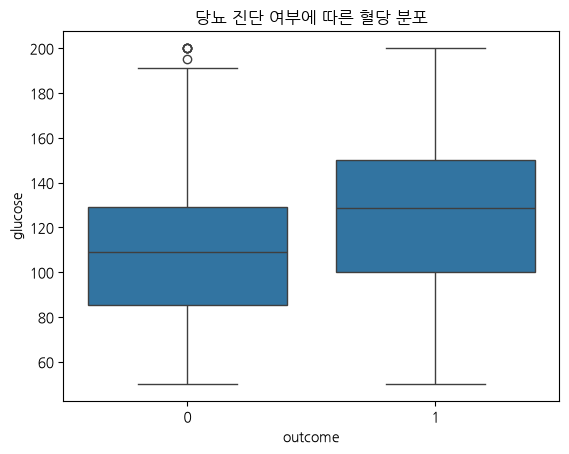

In [4]:
# 답안
sns.boxplot(data=diabetes_df, x='outcome', y='glucose')
plt.xlabel('outcome')
plt.ylabel('glucose')
plt.title('당뇨 진단 여부에 따른 혈당 분포')
plt.show()

3-2. outcome별 glucose 중앙값을 계산하고, 어느 그룹의 중앙값이 더 높은지 확인하세요.

In [5]:
# 여기에 답안을 작성하세요.
glucose_median = diabetes_df.groupby('outcome')['glucose'].median()
print(glucose_median)

outcome
0    109.0
1    128.5
Name: glucose, dtype: float64


3-3. 박스플롯만으로 확인하기 어려운 정보를 고르세요.
다음 중 박스플롯만으로 확인하기 어려운 정보는 무엇인가요?

1. 데이터의 중앙값
2. 이상치 여부
3. 데이터의 정확한 평균값
4. 데이터의 분포 범위

In [6]:
# 답안
# 
# 3 -> (정확한 평균값을 알고 싶으면 별도로 계산 필요)

----
#### 문제 04
당뇨 진단 여부에 따라 BMI 분포가 어떻게 다른지 확인하려 합니다.

4-1. outcome별 bmi 분포를 히스토그램으로 시각화하세요.

조건은 다음과 같습니다.

- sns.histplot()을 사용하세요.
- x축은 bmi로 설정하세요.
- hue='outcome'을 사용하세요.
- kde=True를 설정하세요.
- 그래프 제목은 '당뇨 진단 여부에 따른 BMI 분포'로 설정하세요.

Text(0.5, 1.0, '당뇨 진단 여부에 따른 BMI 분포')

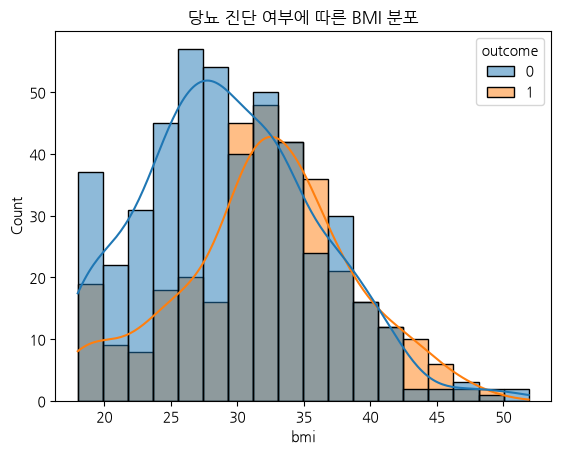

In [7]:
# 답안
sns.histplot(data=diabetes_df, x='bmi', hue='outcome', kde= True)
plt.title('당뇨 진단 여부에 따른 BMI 분포')

4-2. outcome별 BMI 평균과 중앙값을 계산하세요.

In [8]:
# 여기에 답안을 작성하세요.
bmi_stat = diabetes_df.groupby('outcome')['bmi'].median()
print(bmi_stat)

outcome
0    28.95
1    32.40
Name: bmi, dtype: float64


---
#### 문제 05
insulin 컬럼의 결측치를 중앙값으로 처리하세요.

조건은 다음과 같습니다.

- 결측치 처리 전 insulin 컬럼의 결측치 개수를 출력하세요.
- insulin 컬럼의 중앙값을 계산하세요.
- insulin 컬럼의 결측치를 중앙값으로 대체하세요.
- 결측치 처리 후 전체 결측치 개수를 출력하세요.

In [9]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression

print('처리 전 insulin 결측치:', diabetes_df['insulin'].isnull().sum())

# 여기에 답안을 작성하세요.
insulin_median = diabetes_df['insulin'].median()
print('insulin 중앙값:', insulin_median)

# 여기에 답안을 작성하세요.
diabetes_df['insulin'] = diabetes_df['insulin'].fillna(insulin_median)
print('처리 후 전체 결측치 수:', diabetes_df.isnull().sum().sum())

처리 전 insulin 결측치: 48
insulin 중앙값: 68.0
처리 후 전체 결측치 수: 0


#### 문제 06
수치형 변수와 타깃 변수 outcome의 관계를 확인하려 합니다.

6-1. 상관계수 행렬을 계산하고 Heatmap으로 시각화하세요.

조건은 다음과 같습니다.

- diabetes_df.corr()를 사용하세요.
- sns.heatmap()을 사용하세요.
- annot=True를 설정하세요.
- 소수점 둘째 자리까지 표시하세요.

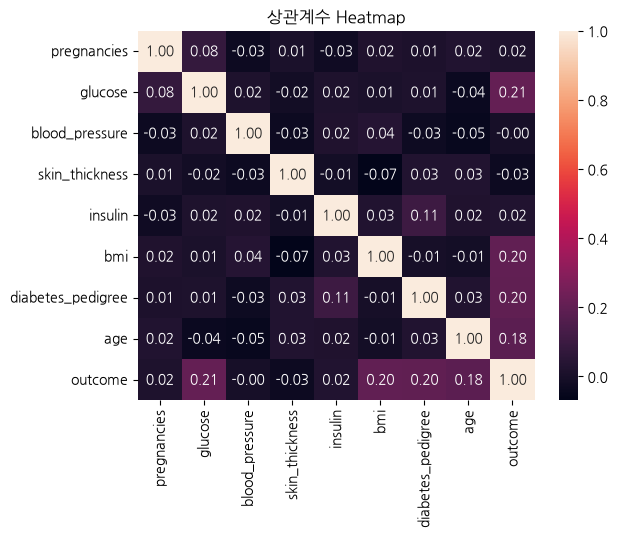

In [10]:
corr = diabetes_df.corr()

# 여기에 답안을 작성하세요.
sns.heatmap(data=corr, annot=True, fmt='.2f')
plt.title('상관계수 Heatmap')
plt.show()

6-2. outcome과 가장 상관계수가 높은 변수를 찾으세요.

In [11]:
# 상관계수가 높은 변수 구하는 법 검색
# [target_corr.index != 'outcome'] -> .index추가, 1.00 -> 'outcome' 변경
# .index를 빼면 실수와 문자열을 비교하게 되어 의도한 필터링이 되지 않음

# 여기에 답안을 작성하세요.
target_corr = corr.outcome
target_corr = target_corr[target_corr.index != 'outcome']  # 자신 제외
target_corr = target_corr.abs().sort_values(ascending=False)
print(target_corr)

glucose              0.208016
bmi                  0.198478
diabetes_pedigree    0.197007
age                  0.184748
skin_thickness       0.032445
insulin              0.024583
pregnancies          0.016714
blood_pressure       0.004512
Name: outcome, dtype: float64


---
#### 문제 07
outcome 컬럼을 타깃 변수로 사용하여 피처와 레이블을 분리하고, 훈련 데이터와 검증 데이터로 나누세요.

조건은 다음과 같습니다.

- outcome 컬럼은 y로 저장하세요.
- 나머지 컬럼은 X로 저장하세요.
- train_test_split()을 사용하세요.
- 검증 데이터 비율은 25%로 설정하세요.
- random_state=42를 설정하세요.
- 클래스 비율을 유지하기 위해 stratify=y를 사용하세요.

In [12]:
from sklearn.model_selection import train_test_split

# 여기에 답안을 작성하세요.
X = diabetes_df.drop('outcome', axis=1)
y = diabetes_df['outcome']

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
print('학습 세트:', X_train.shape)
print('검증 세트:', X_valid.shape)

학습 세트: (600, 8)
검증 세트: (200, 8)


---
#### 문제 08
수치형 변수들의 스케일을 표준화하려 합니다.

8-1. StandardScaler를 올바르게 적용하세요.

조건은 다음과 같습니다.

- StandardScaler를 import하세요.
- ss 변수에 StandardScaler() 객체를 생성하세요.
- 훈련 데이터 X_train에는 fit_transform()을 적용하세요.
- 검증 데이터 X_valid에는 transform()을 적용하세요.
- 스케일링 후 훈련 데이터의 전체 평균과 표준편차를 출력하세요.

In [13]:
# fit_transform -> 한 번에 학습 + 적용
# transform -> 이미 학습된 기준을 그대로 적용만 할 데이터

from sklearn.preprocessing import StandardScaler
# 여기에 답안을 작성하세요.
ss = StandardScaler()
X_train_scaled = ss.fit_transform(X_train)
X_valid_scaled = ss.transform(X_valid)

train_mean = X_train_scaled.mean()
train_std = X_train_scaled.std()

print('훈련 데이터 평균:', train_mean)
print('훈련 데이터 표준편차:', train_std)

훈련 데이터 평균: 8.770761894538737e-17
훈련 데이터 표준편차: 1.0


8-2. 스케일링된 검증 데이터의 전체 최댓값을 반올림하여 출력하세요.

In [14]:
# 여기에 답안을 작성하세요.
max_value = X_valid_scaled.max().round(1)
print(max_value)

4.3


---
#### 문제 09
당뇨 진단 여부를 예측하기 위해 두 개의 분류 모델을 학습하세요.

9-1. LogisticRegression 모델을 학습하세요.

조건은 다음과 같습니다.

- 모델은 model_lr 변수에 저장하세요.
- max_iter=1000을 설정하세요.
- random_state=42를 설정하세요.
- 학습 데이터는 X_train, y_train을 사용하세요.

In [15]:
from sklearn.linear_model import LogisticRegression

# 여기에 답안을 작성하세요.
model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_train_scaled, y_train)

print('LR 학습 완료')

LR 학습 완료


9-2. RandomForestClassifier 모델을 학습하세요.

조건은 다음과 같습니다.

- RandomForestClassifier를 임포트하세요.
- 모델은 model_rf 변수에 저장하세요.
- n_estimators=100을 설정하세요.
- random_state=42를 설정하세요.
- 학습 데이터는 X_train, y_train을 사용하세요.

In [16]:
# 여기에 답안을 작성하세요.
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train_scaled, y_train)

print('RF 학습 완료')

RF 학습 완료


In [35]:
print('RF 훈련 정확도:', model_lr.score(X_train_scaled, y_train))
print('RF 검증 정확도:', model_lr.score(X_valid_scaled, y_valid))

RF 훈련 정확도: 0.6716666666666666
RF 검증 정확도: 0.705


In [34]:
print('RF 훈련 정확도:', model_rf.score(X_train_scaled, y_train))
print('RF 검증 정확도:', model_rf.score(X_valid_scaled, y_valid))

RF 훈련 정확도: 1.0
RF 검증 정확도: 0.69


---
#### 문제 10
앞서 학습한 두 모델의 Accuracy를 계산하고 비교하세요.

10-1. LogisticRegression과 RandomForestClassifier의 Accuracy를 계산하세요.

조건은 다음과 같습니다.

- 필요한 모듈을 임포트하세요.
- accuracy_score를 사용하세요.
- 검증 데이터 X_valid를 사용하여 예측하세요.
- 두 모델의 Accuracy를 소수점 넷째 자리까지 출력하세요.

In [17]:
from sklearn.metrics import accuracy_score
# 여기에 답안을 작성하세요.

lr_pred = model_lr.predict(X_valid_scaled)
rf_pred = model_rf.predict(X_valid_scaled)

lr_acc = accuracy_score(y_valid, lr_pred)
rf_acc = accuracy_score(y_valid, rf_pred)

print(f'LR Accuracy: {lr_acc:.4f}')
print(f'RF Accuracy: {rf_acc:.4f}')

LR Accuracy: 0.7050
RF Accuracy: 0.6900


10-2. Accuracy 기준으로 더 우수한 모델을 출력하고, Accuracy만으로 평가할 때의 한계를 설명하세요.

In [18]:
# 답안
# 이 결과에서는 LogisticRegression의 Accuracy가 RandomForestClassifier보다 약간 높습니다.
# accuracy만으로 모델을 평가할 때의 주요 한계는 클래스 불균형 문제와 오류 유형을 구분하지 못한다는 것입니다.

---
#### 문제 11
RandomForest 모델이 예측에 중요하게 사용한 변수를 확인하려 합니다.

11-1. 특성 중요도를 DataFrame으로 정리하세요.

조건은 다음과 같습니다.

- 변수명은 X의 컬럼명을 사용하세요.
- 중요도는 model_rf.feature_importances_를 사용하세요.
- 중요도 기준으로 내림차순 정렬하세요.
- 상위 5개 변수를 출력하세요.

In [27]:
# 답안
feature_importances = pd.DataFrame({'features' : X.columns,
                                    'importance': model_rf.feature_importances_})

feature_importances = feature_importances.sort_values(by='importance', ascending=False)

print(feature_importances.head(5))

            features  importance
1            glucose    0.167420
5                bmi    0.164772
6  diabetes_pedigree    0.156345
7                age    0.134184
4            insulin    0.110538


11-2. 특성 중요도를 수평 막대그래프로 시각화하세요.
- x는 importance, y는 features
- 그래프의 제목은 'RandomForest 특성 중요도'라고 합니다.

Text(0.5, 1.0, 'RandomForest 특성 중요도')

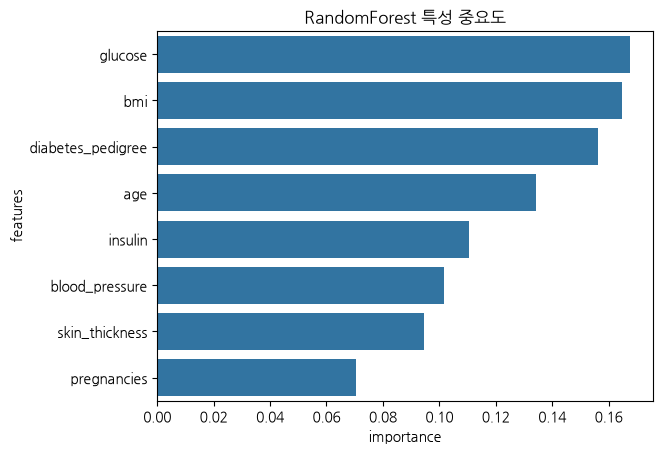

In [28]:
# 답안
sns.barplot(data=feature_importances, x='importance', y='features')
plt.xlabel('importance')
plt.ylabel('features')
plt.title('RandomForest 특성 중요도')

---
#### 문제 12
RandomForest 모델의 예측 결과를 혼동 행렬로 확인하고, 당뇨 클래스 기준 성능을 평가하세요.

12-1. RandomForest 모델의 혼동 행렬을 계산하세요.

조건은 다음과 같습니다.

- confusion_matrix를 사용하세요.
- 실제값은 y_valid, 예측값은 y_pred_rf를 사용하세요.
- 결과를 DataFrame으로 변환하세요.
- 행은 실제값, 열은 예측값을 의미하도록 인덱스와 컬럼명을 지정하세요.

In [ ]:
# DataFrame 공식 검색

from sklearn.metrics import confusion_matrix
# 여기에 답안을 작성하세요.
cm = confusion_matrix(y_valid,rf_pred)
cm_df = pd.DataFrame(cm,
                     index=['실제_0', '실제_1'],
                     columns=['예측_0', '예측_1'])
cm_df

,예측_0,예측_1
실제_0,95,23
실제_1,39,43


12-2. 당뇨 클래스 기준 Precision, Recall, F1-score를 계산하세요.

조건은 다음과 같습니다.

- 당뇨 클래스 1을 기준으로 계산하세요.
- precision_score, recall_score, f1_score를 사용하세요.
- 각 지표는 소수점 넷째 자리까지 출력하세요.

In [ ]:
# pos_label=1로 당뇨 클래스 1을 기준

from sklearn.metrics import f1_score, precision_score, recall_score
# 여기에 답안을 작성하세요.

precision = precision_score(y_valid, rf_pred, pos_label=1)
recall = recall_score(y_valid, rf_pred, pos_label=1)
f1 = f1_score(y_valid, rf_pred, pos_label=1)

print(f'Precision:, {precision:.4f}')
print(f'Recall:, {recall:.4f}')
print(f'F1-score:, {f1:.4f}')

Precision:, 0.6515
Recall:, 0.5244
F1-score:, 0.5811


---
#### 문제 13
TensorFlow Keras를 사용하여 당뇨 진단 여부를 예측하는 딥러닝 이진 분류 모델을 구성하세요.

13-1. 딥러닝 이진 분류 모델을 정의하고 학습 설정을 준비하세요.

조건은 다음과 같습니다.

- Sequential 모델을 사용하세요.
- 난수의 시드를 고정(42)하세요.
- 첫 번째 은닉층은 Dense(64, activation='relu')로 구성하세요.
- Dropout(0.3)을 추가하세요.
- 두 번째 은닉층은 Dense(32, activation='relu')로 구성하세요.
- 출력층은 Dense(1, activation='sigmoid')로 구성하세요.
- EarlyStopping을 사용하세요.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# 여기에 답안을 작성하세요.

13-2. 이진 분류 모델을 컴파일하고 학습시키세요.

조건은 다음과 같습니다.
- monitor='val_loss', patience=14, restore_best_weights=True로 설정하세요.
- 손실 함수는 binary_crossentropy를 사용하세요.
- 옵티마이저는 adam을 사용하세요.
- 평가지표는 accuracy를 사용하세요.
- 학습데이터와정답은 X_train, y_train 입니다.
- 최대 50번 반복 학습하고, 32개 단위로 묶어 가중치를 업데이트 합니다.
- 매 epoch마다 검증 성능을 평가합니다.
- val_loss 기준 14 epoch 개선이 없으면 조기 종료, 최적 가중치를 복원합니다.
- 학습 로그를 출력하지 않습니다.

In [ ]:
# 여기에 답안을 작성하세요.
print('딥러닝 모델 학습 완료')

---
#### 문제 14
딥러닝 모델의 학습 과정과 검증 성능을 확인하려 합니다.

14-1. 학습 Accuracy와 검증 Accuracy를 시각화하세요.

조건은 다음과 같습니다.

- 학습 Accuracy와 검증 Accuracy를 하나의 그래프에 함께 표시하세요.
- 범례는 각각 'train accuracy', 'validation accuracy'로 표시하세요.
- 그래프 제목은 'Model Accuracy'로 설정하세요.

In [ ]:
# 답안


14-2. 최고 검증 Accuracy와 해당 epoch를 출력하세요.

In [ ]:
# 여기에 답안을 작성하세요.

print('최고 검증 Accuracy:', round(best_val_acc, 4))
print('최고 검증 Accuracy epoch:', best_epoch)

14-3. 마지막 epoch 기준 학습 Accuracy와 검증 Accuracy의 차이를 계산하세요.

In [ ]:
# 여기에 답안을 작성하세요.

print('마지막 학습 Accuracy:', round(last_train_acc, 4))
print('마지막 검증 Accuracy:', round(last_val_acc, 4))
print('Accuracy 차이:', round(gap, 4))